In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("netflix_titles_clean.csv")

# Display first five rows
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,25-Sep-21,2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,24-Sep-21,2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,24-Sep-21,2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,24-Sep-21,2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [2]:
#21. Which content categories should Netflix invest more in?

genre_popularity = (
    df.assign(listed_in=df['listed_in'].str.split(', '))
      .explode('listed_in')
      .groupby('listed_in')
      .size()
      .sort_values(ascending=False)
)

print(genre_popularity.head(15))

listed_in
International Movies        2752
Dramas                      2427
Comedies                    1674
International TV Shows      1351
Documentaries                869
Action & Adventure           859
TV Dramas                    763
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
TV Comedies                  581
Thrillers                    577
Crime TV Shows               470
Kids' TV                     451
Docuseries                   395
dtype: int64


In [3]:
#22. Which markets are underrepresented?

country_count = (
    df.assign(country=df['country'].str.split(', '))
      .explode('country')['country']
      .value_counts()
)

underrepresented = country_count[country_count < 10]

print(underrepresented.sort_values())

Uganda           1
Sri Lanka        1
Palestine        1
Liechtenstein    1
Kazakhstan       1
                ..
Kenya            6
Vietnam          7
Serbia           7
Kuwait           8
Jordan           9
Name: country, Length: 72, dtype: int64


In [4]:
#23. Which countries consistently produce mature-rated content?

mature = df[df['rating'].isin(['TV-MA','R','NC-17'])]

mature_country = (
    mature.assign(country=mature['country'].str.split(', '))
          .explode('country')['country']
          .value_counts()
)

print(mature_country.head(15))

United States     1761
United Kingdom     396
India              271
France             221
Canada             187
Spain              184
Germany            122
Mexico             116
Japan              110
South Korea         94
Argentina           69
Turkey              69
Australia           65
Belgium             64
Brazil              62
Name: country, dtype: int64


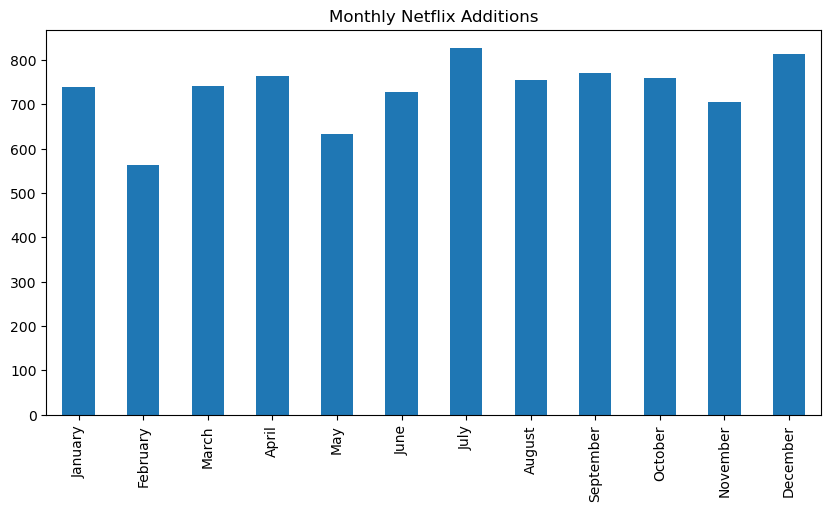

In [5]:
#24. Which months see the highest number of content additions?

df['date_added'] = pd.to_datetime(df['date_added'])

monthly = (
    df['date_added']
    .dt.month_name()
    .value_counts()
)

months = [
    'January','February','March','April','May','June',
    'July','August','September','October','November','December'
]

monthly = monthly.reindex(months)

monthly.plot(kind='bar', figsize=(10,5))

plt.title("Monthly Netflix Additions")
plt.show()

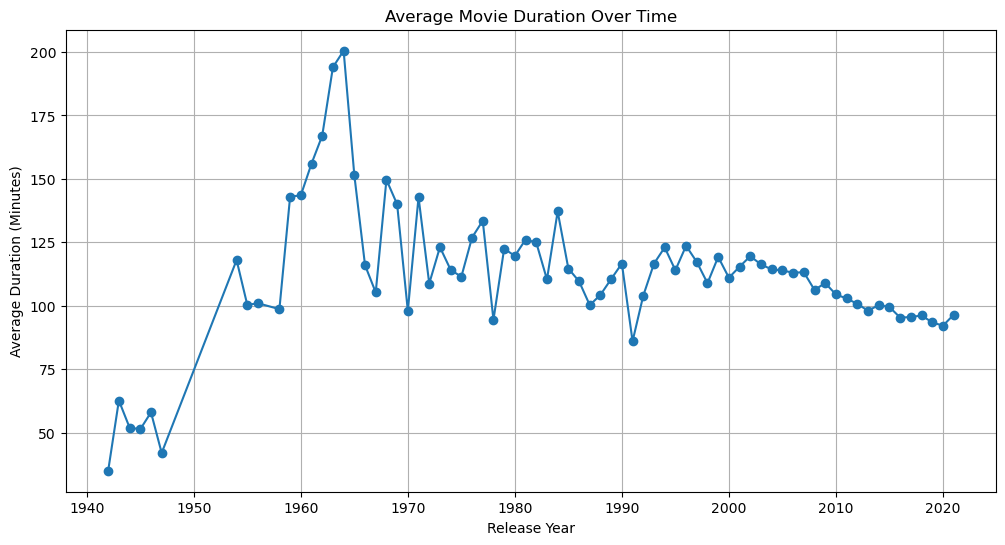

In [7]:
#25. Are Movies becoming shorter over time?

# Filter only movies
movies = df[df['type'] == 'Movie'].copy()

# Remove rows with missing duration or release year
movies = movies.dropna(subset=['duration', 'release_year'])

# Remove " min" from duration
movies['duration'] = movies['duration'].str.replace(' min', '', regex=False)

# Convert duration to numeric
movies['duration'] = pd.to_numeric(movies['duration'], errors='coerce')

# Remove rows where conversion failed
movies = movies.dropna(subset=['duration'])

# Calculate average movie duration by release year
trend = (
    movies.groupby('release_year')['duration']
    .mean()
)

# Plot
plt.figure(figsize=(12,6))
plt.plot(trend.index, trend.values, marker='o')

plt.title("Average Movie Duration Over Time")
plt.xlabel("Release Year")
plt.ylabel("Average Duration (Minutes)")
plt.grid(True)

plt.show()

In [8]:
#26. Which genres are declining?

genre_year = (
    df.assign(listed_in=df['listed_in'].str.split(', '))
      .explode('listed_in')
      .groupby(['release_year','listed_in'])
      .size()
      .unstack(fill_value=0)
)

decline = genre_year.iloc[-1] - genre_year.iloc[-5]

print(decline.sort_values().head(10))

listed_in
Dramas                 -193
International Movies   -187
Documentaries          -119
Independent Movies      -97
Comedies                -94
Action & Adventure      -52
Stand-Up Comedy         -46
Romantic Movies         -39
Thrillers               -35
Horror Movies           -27
dtype: int64


In [9]:
#27. Which directors work across the largest variety of genres?

director_genres = (
    df.assign(director=df['director'].str.split(', '))
      .explode('director')
      .assign(listed_in=df['listed_in'].str.split(', '))
      .explode('listed_in')
)

variety = (
    director_genres.groupby('director')['listed_in']
    .nunique()
    .sort_values(ascending=False)
)

print(variety.head(15))

director
Anurag Kashyap          9
Martin Scorsese         9
Ifa Isfansyah           8
Vikramaditya Motwane    8
Vishal Bhardwaj         8
Abhishek Chaubey        8
Priyadarshan            8
Guillermo del Toro      7
Julien Leclercq         7
Brad Anderson           7
Jeremy Saulnier         7
David Dhawan            7
Manolo Caro             7
Tim Burton              7
BB Sasore               7
Name: listed_in, dtype: int64


In [10]:
#28. Which actors collaborate with the greatest number of directors?

actor_director = (
    df.assign(cast=df['cast'].str.split(', '))
      .explode('cast')
      .assign(director=df['director'].str.split(', '))
      .explode('director')
)

collaboration = (
    actor_director.groupby('cast')['director']
    .nunique()
    .sort_values(ascending=False)
)

print(collaboration.head(15))

cast
James Franco        37
Kristen Bell        32
Naseeruddin Shah    30
Radhika Apte        29
Anupam Kher         29
Amitabh Bachchan    28
Kareena Kapoor      28
Akshay Kumar        27
Alfred Molina       27
Liev Schreiber      25
Shah Rukh Khan      25
Halle Berry         25
Om Puri             25
Paresh Rawal        25
Liam Neeson         24
Name: director, dtype: int64


In [11]:
#29. Which countries produce the widest variety of ratings?

country_rating = (
    df.assign(country=df['country'].str.split(', '))
      .explode('country')
)

rating_variety = (
    country_rating.groupby('country')['rating']
    .nunique()
    .sort_values(ascending=False)
)

print(rating_variety.head(15))

country
United States     17
Canada            13
France            13
United Kingdom    12
Spain             12
South Korea       11
Italy             11
Germany           11
China             11
Belgium           11
India             11
Denmark           10
Japan             10
Australia         10
Ireland           10
Name: rating, dtype: int64


In [12]:
#Which genres dominate each country?

country_genre = (
    df.assign(country=df['country'].str.split(', '))
      .explode('country')
      .assign(listed_in=df['listed_in'].str.split(', '))
      .explode('listed_in')
)

dominant = (
    country_genre
    .groupby(['country','listed_in'])
    .size()
)

dominant = dominant.groupby(level=0).idxmax()

print(dominant)

country
                                          (, Dramas)
Afghanistan             (Afghanistan, Documentaries)
Albania                            (Albania, Dramas)
Algeria                            (Algeria, Dramas)
Angola                  (Angola, Action & Adventure)
                                ...                 
Vatican City           (Vatican City, Documentaries)
Venezuela                 (Venezuela, Documentaries)
Vietnam              (Vietnam, International Movies)
West Germany    (West Germany, International Movies)
Zimbabwe            (Zimbabwe, International Movies)
Length: 127, dtype: object


In [13]:
pip install psycopg2-binary sqlalchemy

Note: you may need to restart the kernel to use updated packages.


In [14]:
from sqlalchemy import create_engine


#Step 1:- Connect to postgreSQL

username ="postgres"
password ="rehan"
host ="localhost"
port ="5432"
database ="netflix_analysis"

engine = create_engine(f"postgresql+psycopg2://{username}:{password}@{host}:{port}/{database}")

#Step 2:- Load Dataframe into postgreSQL

table_name ="netflix_analysis"
df.to_sql(table_name, engine, if_exists="replace", index=False)

print(f"Data successfully loaded into table '{table_name}' in database '{database}'.")

Data successfully loaded into table 'netflix_analysis' in database 'netflix_analysis'.
